In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "C:/Users/rames/notebook/DS-1\data/processed/final_feature_dataset.csv"
)

In [3]:
print("Shape :", df.shape)

Shape : (114100, 58)


In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,delivery_days,delivery_delay_days,total_order_value,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_day,is_weekend,delivery_completed,delivery_status,freight_percentage,product_volume_cm3,weight_category,description_quality,total_orders,total_spending,customer_average_order_value,Recency,Frequency,Monetary,price_category,order_status_encoded,payment_type_encoded
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,credit_card,4,8.0,-8.0,38.71,2017,10,October,4,Monday,0,1,On Time,22.526479,1976.0,Light,Short,2,82.82,41.41,380,2,82.82,Unknown,3,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,4,13.0,-6.0,141.46,2018,7,July,3,Tuesday,0,1,On Time,16.089354,4693.0,Light,Short,1,141.46,141.46,84,1,141.46,Low,3,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,5,9.0,-18.0,179.12,2018,8,August,3,Wednesday,0,1,On Time,10.730237,9576.0,Light,Short,1,179.12,179.12,70,1,179.12,Low,3,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,72.20,1.0,credit_card,5,13.0,-13.0,72.20,2017,11,November,4,Saturday,1,1,On Time,37.673130,6000.0,Light,Short,1,72.20,72.20,332,1,72.20,Unknown,3,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,5,2.0,-10.0,28.62,2018,2,February,1,Tuesday,0,1,On Time,30.468204,11475.0,Light,Short,1,28.62,28.62,245,1,28.62,Unknown,3,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114100 entries, 0 to 114099
Data columns (total 58 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114100 non-null  object 
 1   customer_id                    114100 non-null  object 
 2   order_status                   114100 non-null  object 
 3   order_purchase_timestamp       114100 non-null  object 
 4   order_approved_at              114100 non-null  object 
 5   order_delivered_carrier_date   114100 non-null  object 
 6   order_delivered_customer_date  114100 non-null  object 
 7   order_estimated_delivery_date  114100 non-null  object 
 8   customer_unique_id             114100 non-null  object 
 9   customer_zip_code_prefix       114100 non-null  int64  
 10  customer_city                  114100 non-null  object 
 11  customer_state                 114100 non-null  object 
 12  order_item_id                 

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
total_revenue = df["total_order_value"].sum()

print(f"Total Revenue : {total_revenue:,.2f}")

Total Revenue : 15,917,317.93


In [8]:
total_orders = df["order_id"].nunique()

print(total_orders)

99441


In [9]:
total_customers = df["customer_unique_id"].nunique()

print(total_customers)

96096


In [10]:
average_order_value = df["total_order_value"].mean()

print(round(average_order_value,2))

139.5


In [11]:
products_sold = df["product_id"].nunique()

print(products_sold)

32952


In [12]:
monthly_sales = (

df.groupby("purchase_month_name")

["total_order_value"]

.sum()

.reset_index()

)

In [13]:
month_order = [

"January",
"February",
"March",
"April",
"May",
"June",
"July",
"August",
"September",
"October",
"November",
"December"

]

monthly_sales["purchase_month_name"] = pd.Categorical(

monthly_sales["purchase_month_name"],

categories=month_order,

ordered=True

)

monthly_sales = monthly_sales.sort_values(
"purchase_month_name"
)

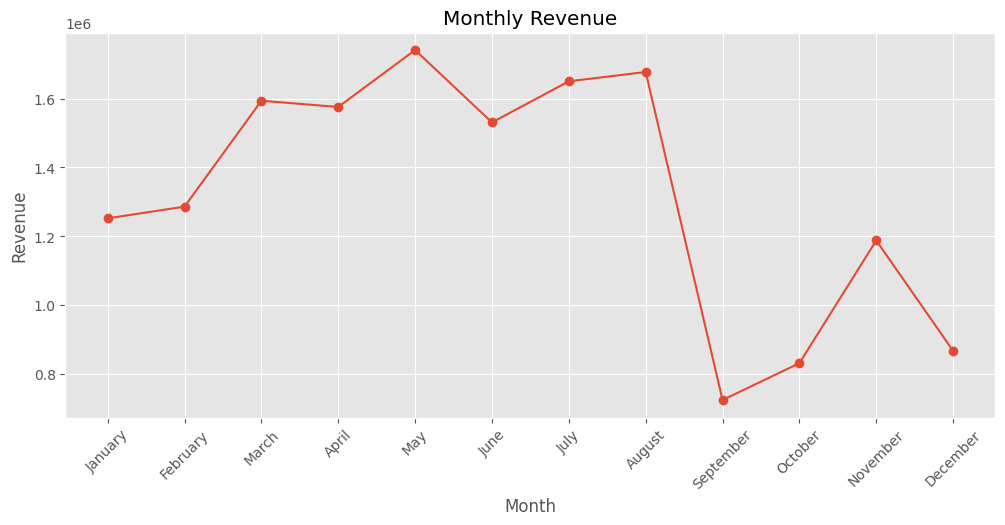

In [14]:
plt.figure(figsize=(12,5))

plt.plot(

monthly_sales["purchase_month_name"],

monthly_sales["total_order_value"],

marker="o"

)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

In [15]:
state_sales = (

df.groupby("customer_state")

["total_order_value"]

.sum()

.sort_values(ascending=False)

.head(10)

)

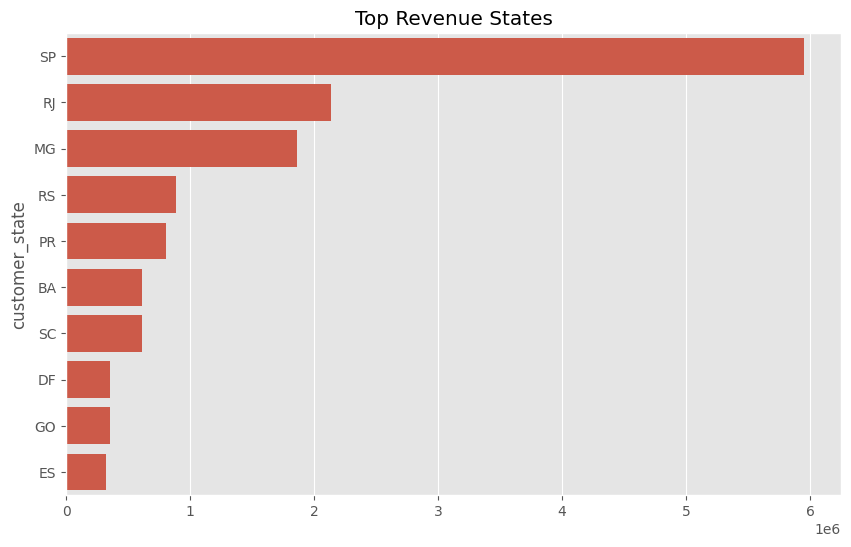

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(

x=state_sales.values,

y=state_sales.index

)

plt.title("Top Revenue States")

plt.show()

In [17]:
category_df = df[
    df["product_category_name_english"] != "Unknown"
]

In [18]:
category_sales = (

category_df

.groupby(
"product_category_name_english"
)

["total_order_value"]

.sum()

.sort_values(ascending=False)

.head(10)

)

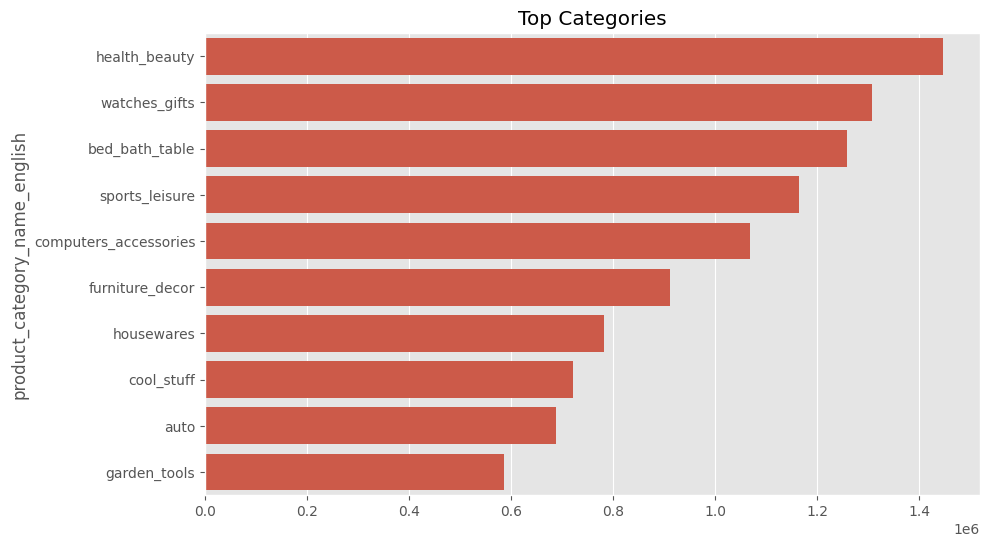

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(

x=category_sales.values,

y=category_sales.index

)

plt.title("Top Categories")

plt.show()

In [20]:
status = df["order_status"].value_counts()

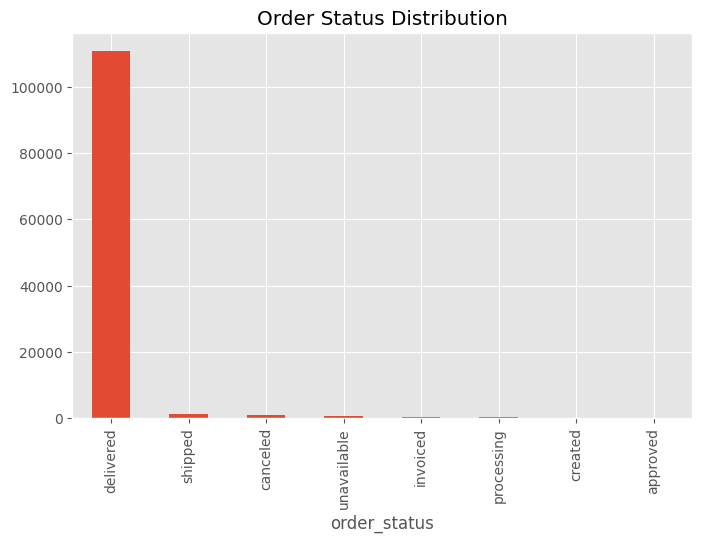

In [21]:
plt.figure(figsize=(8,5))

status.plot(

kind="bar"

)

plt.title("Order Status Distribution")

plt.show()

In [22]:
payment = (

df["payment_type"]

.value_counts()

)

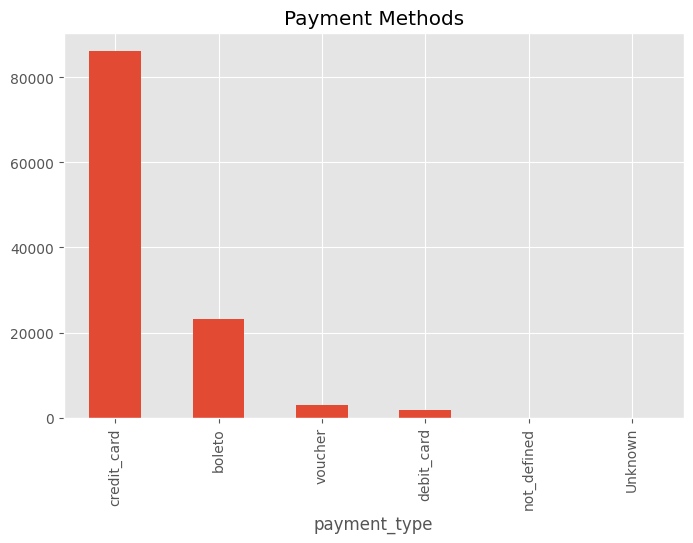

In [23]:
plt.figure(figsize=(8,5))

payment.plot(

kind="bar"

)

plt.title("Payment Methods")

plt.show()

In [24]:
delivery_df = df[
    df["delivery_completed"] == 1
]

In [25]:
average_delivery = (

delivery_df["delivery_days"]

.mean()

)

print(round(average_delivery,2))

12.01


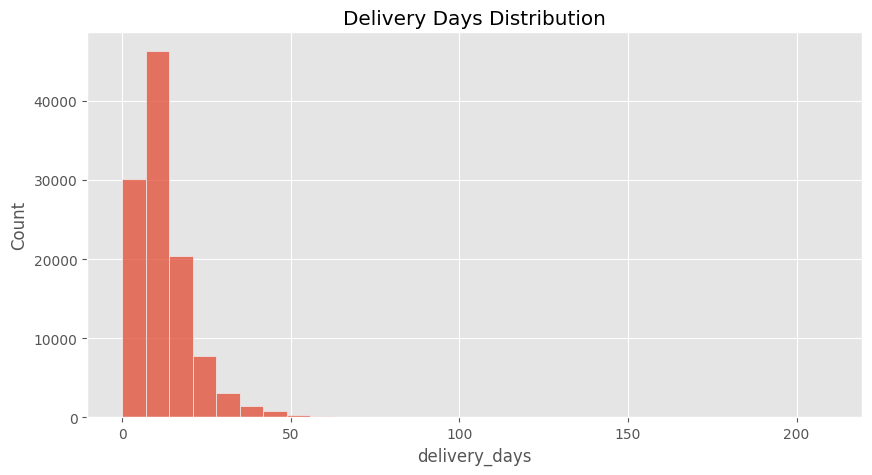

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(

delivery_df["delivery_days"],

bins=30

)

plt.title("Delivery Days Distribution")

plt.show()

In [27]:
top_customers = (

df.groupby("customer_unique_id")

["total_order_value"]

.sum()

.sort_values(ascending=False)

.head(10)

)

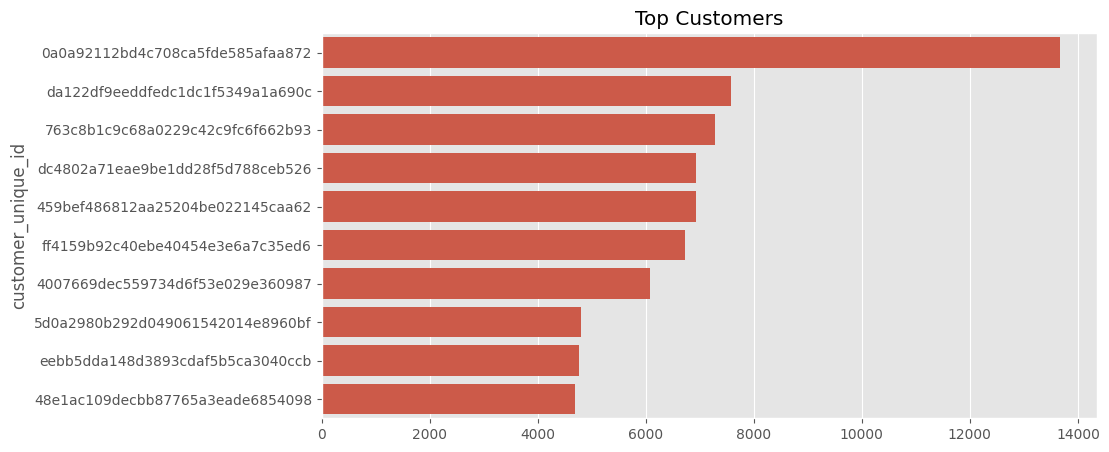

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(

x=top_customers.values,

y=top_customers.index

)

plt.title("Top Customers")

plt.show()

In [29]:
weekend_sales = (

df.groupby("is_weekend")

["total_order_value"]

.sum()

)

In [30]:
weekend_sales.index = [

"Weekday",

"Weekend"

]

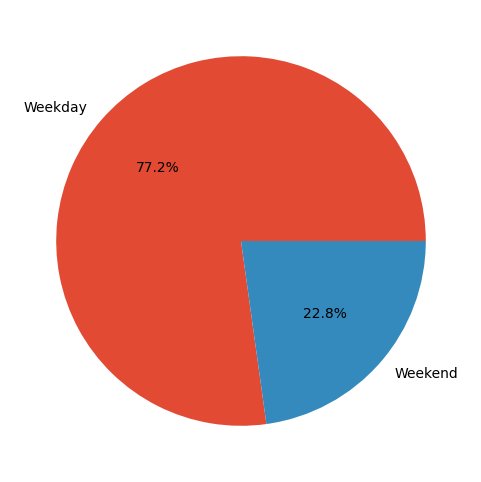

In [31]:
weekend_sales.plot(

kind="pie",

autopct="%1.1f%%",

figsize=(6,6)

)

plt.ylabel("")

plt.show()

In [32]:
product_df = df[
    df["product_id"] != "Unknown"
]

In [33]:
top_products = (

product_df.groupby(
"product_id"
)

["total_order_value"]

.sum()

.sort_values(ascending=False)

.head(10)

)

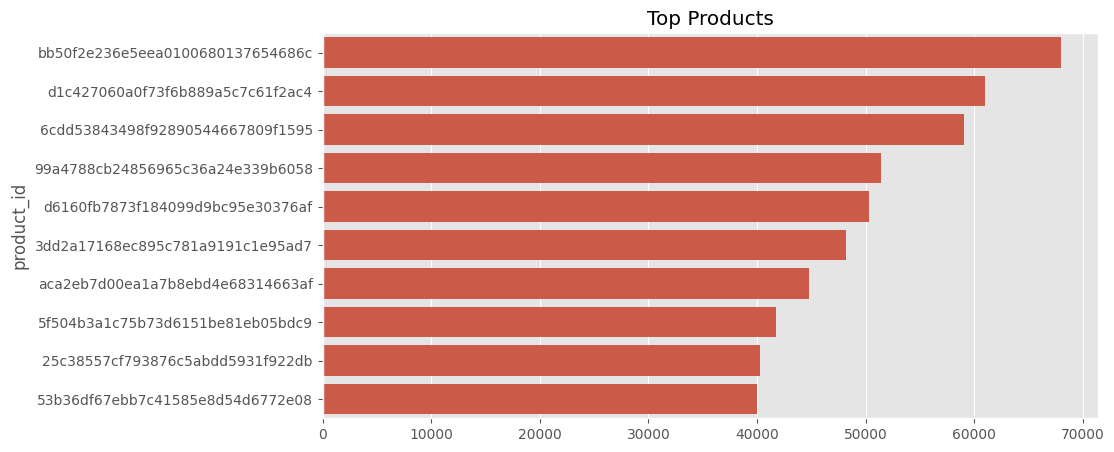

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(

x=top_products.values,

y=top_products.index

)

plt.title("Top Products")

plt.show()

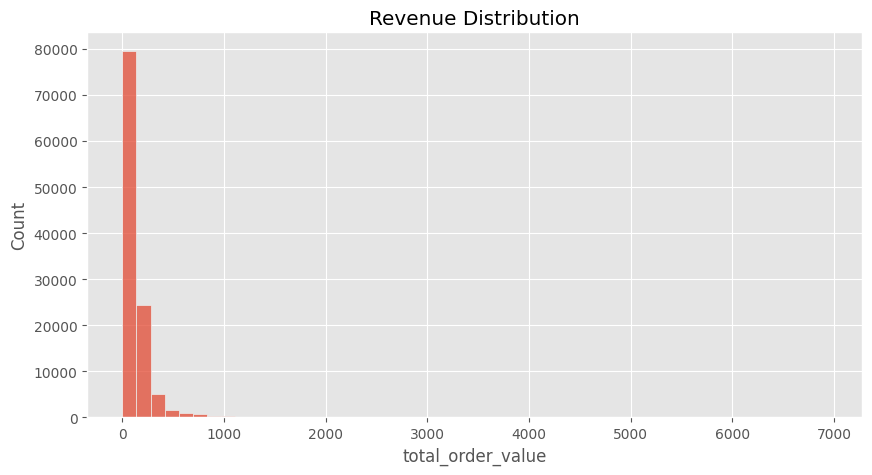

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(

df["total_order_value"],

bins=50

)

plt.title("Revenue Distribution")

plt.show()

In [37]:
monthly_sales.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/sales/monthly_sales.csv",
    index=False
)

category_sales.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/sales/category_sales.csv"
)

state_sales.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/sales/state_sales.csv"
)

# Business Insights

1. Revenue varies significantly across months.

2. A small number of product categories contribute a large share of total revenue.

3. Certain states consistently generate higher revenue.

4. Most customers use a limited set of payment methods.

5. Delivered orders dominate the dataset, while cancelled and unavailable orders represent a small fraction.

6. Average delivery time is an important operational KPI.

7. Top customers contribute disproportionately to total revenue.

# Conclusion

In this notebook, we analyzed retail sales performance using the engineered dataset.

Key achievements:

- Calculated executive KPIs
- Analyzed monthly sales trends
- Identified top-performing states
- Measured category performance
- Evaluated payment methods
- Analyzed delivery performance
- Identified top customers and products

The generated insights will be used in the next phase to perform customer segmentation and advanced customer analytics.